# Qwen3 + Dolos Code Similarity Notebook


## 1. Setup and configuration

Adjust `LANGUAGE` and `CORPUS_PATH` in the code cell below before running the experiment.

In [69]:
import os
from pathlib import Path
from dotenv import load_dotenv
from openai import OpenAI
from google import genai

# --- Project paths ---
PROJECT_DIR = Path(r"C:\Users\Feresh\Documents\EPRP_Final")
ENV_PATH    = PROJECT_DIR / ".env"
WRAPPER_PY  = PROJECT_DIR / "dolos_wrapper.py"
DATA_DIR    = PROJECT_DIR / "data"

print("PROJECT_DIR:", PROJECT_DIR)
print(".env exists:", ENV_PATH.exists(), "->", ENV_PATH)
print("wrapper exists:", WRAPPER_PY.exists(), "->", WRAPPER_PY)
print("data dir exists:", DATA_DIR.exists(), "->", DATA_DIR)

# --- Load .env cleanly ---
if not ENV_PATH.exists():
    raise RuntimeError(f".env not found at {ENV_PATH}")
load_dotenv(dotenv_path=ENV_PATH, override=True)

# --- Docker image for Dolos wrapper ---
os.environ["DOLOS_DOCKER_IMAGE"] = "copyleft-guard-data"

# --- HF token (HF Router) ---
HF_TOKEN = os.environ.get("HF_TOKEN") or os.environ.get("HUGGINGFACEHUB_API_TOKEN")
if not HF_TOKEN:
    raise RuntimeError("HF_TOKEN (or HUGGINGFACEHUB_API_TOKEN) missing in .env")

# --- Gemini key ---
GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY")
if not GEMINI_API_KEY:
    raise RuntimeError("GEMINI_API_KEY missing in .env")

# --- OpenAI key ---
OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY")
if not OPENAI_API_KEY:
    raise RuntimeError("OPENAI_API_KEY missing in .env")

# --- Models ---
QWEN_MODEL          = "Qwen/Qwen3-30B-A3B-Instruct-2507:nebius"
DEEPSEEK_MODEL      = "deepseek-ai/DeepSeek-V3.2:novita"
GEMINI_LITE_MODEL   = "gemini-2.5-flash-lite"
OPENAI_MODEL        = "gpt-4o-mini-2024-07-18"  

print("HF Models:", QWEN_MODEL, "vs", DEEPSEEK_MODEL)
print("Gemini Model:", GEMINI_LITE_MODEL)
print("OpenAI Model:", OPENAI_MODEL)

# --- HF Router client (shared) ---
_hf_client: OpenAI | None = None

def get_hf_client() -> OpenAI:
    global _hf_client
    if _hf_client is None:
        _hf_client = OpenAI(
            base_url="https://router.huggingface.co/v1",
            api_key=HF_TOKEN,
        )
    return _hf_client

def call_hf_chat(prompt: str, model: str, temperature: float, max_new_tokens: int = 256, n: int = 1) -> list[str]:
    client = get_hf_client()
    resp = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        max_tokens=max_new_tokens,
        n=n,
        temperature=temperature,
    )
    return [(c.message.content or "").strip() for c in resp.choices if c.message and c.message.content]

def call_qwen(prompt: str, temperature: float, n: int = 1, max_new_tokens: int = 256) -> list[str]:
    return call_hf_chat(prompt, model=QWEN_MODEL, temperature=temperature, max_new_tokens=max_new_tokens, n=n)

def call_deepseek(prompt: str, temperature: float, n: int = 1, max_new_tokens: int = 256) -> list[str]:
    return call_hf_chat(prompt, model=DEEPSEEK_MODEL, temperature=temperature, max_new_tokens=max_new_tokens, n=n)

# --- Gemini client (shared) ---
_gemini_client: genai.Client | None = None

def get_gemini_client() -> genai.Client:
    global _gemini_client
    if _gemini_client is None:
        _gemini_client = genai.Client(api_key=GEMINI_API_KEY)
    return _gemini_client

def call_gemini(prompt: str, model: str, temperature: float, max_new_tokens: int = 256, n: int = 1) -> list[str]:
    client = get_gemini_client()
    out: list[str] = []
    for _ in range(n):
        resp = client.models.generate_content(
            model=model,
            contents=prompt,
            config={"temperature": temperature, "max_output_tokens": max_new_tokens},
        )
        text = (getattr(resp, "text", "") or "").strip()
        if text:
            out.append(text)
    return out

def call_gemini_flash_lite(prompt: str, temperature: float, n: int = 1, max_new_tokens: int = 256) -> list[str]:
    return call_gemini(prompt, model=GEMINI_LITE_MODEL, temperature=temperature, max_new_tokens=max_new_tokens, n=n)

# --- OpenAI client (shared) ---
_openai_client: OpenAI | None = None

def get_openai_client() -> OpenAI:
    global _openai_client
    if _openai_client is None:
        _openai_client = OpenAI(api_key=OPENAI_API_KEY)
    return _openai_client

def call_openai_chat(prompt: str, model: str, temperature: float, max_new_tokens: int = 256, n: int = 1) -> list[str]:
    client = get_openai_client()
    resp = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        max_tokens=max_new_tokens,
        n=n,
        temperature=temperature,
    )
    return [(c.message.content or "").strip() for c in resp.choices if c.message and c.message.content]

def call_gpt4o_mini(prompt: str, temperature: float, n: int = 1, max_new_tokens: int = 256) -> list[str]:
    return call_openai_chat(prompt, model=OPENAI_MODEL, temperature=temperature, max_new_tokens=max_new_tokens, n=n)

# --- MODELS list for your experiment loop ---
MODELS = [
    ("qwen", QWEN_MODEL, call_qwen),
    ("deepseek", DEEPSEEK_MODEL, call_deepseek),
    ("gemini_flash_lite", GEMINI_LITE_MODEL, call_gemini_flash_lite),
    ("gpt4o_mini_2024_07_18", OPENAI_MODEL, call_gpt4o_mini),
]


PROJECT_DIR: C:\Users\Feresh\Documents\EPRP_Final
.env exists: True -> C:\Users\Feresh\Documents\EPRP_Final\.env
wrapper exists: True -> C:\Users\Feresh\Documents\EPRP_Final\dolos_wrapper.py
data dir exists: True -> C:\Users\Feresh\Documents\EPRP_Final\data
HF Models: Qwen/Qwen3-30B-A3B-Instruct-2507:nebius vs deepseek-ai/DeepSeek-V3.2:novita
Gemini Model: gemini-2.5-flash-lite
OpenAI Model: gpt-4o-mini-2024-07-18


In [136]:
# --- experiment config ---
TEMPERATURES = [0.2, 0.4, 0.8]
MAX_NEW_TOKENS = 256
N_SAMPLES_PER_FUNC = 1

# --- corpus / language selection ---
LANGUAGE = "scala"  
CORPUS_PATH = DATA_DIR / f"corpus_{LANGUAGE}_copyleft.jsonl"

print("Language:", LANGUAGE)
print("Corpus:", CORPUS_PATH, "exists:", CORPUS_PATH.exists())

if not CORPUS_PATH.exists():
    raise RuntimeError(f"Corpus file not found: {CORPUS_PATH}")


Language: scala
Corpus: C:\Users\Feresh\Documents\EPRP_Final\data\corpus_scala_copyleft.jsonl exists: True


## 2. Load JSON corpus and sanity checks

In [137]:
import json
from pathlib import Path

def load_corpus(path: Path, max_rows: int | None = None):
    entries = []
    with path.open("r", encoding="utf-8", errors="replace") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                entries.append(json.loads(line))
            except Exception:
                continue
            if max_rows is not None and len(entries) >= max_rows:
                break
    return entries

entries = load_corpus(CORPUS_PATH)
print("Total snippets in corpus:", len(entries))
if entries:
    print("Example keys:", sorted(entries[0].keys()))


Total snippets in corpus: 53684
Example keys: ['code_normalized', 'code_original', 'filepath', 'language', 'license', 'n_lines', 'qualified_name', 'repo_dir', 'sha256_normalized', 'sha256_original', 'standalone']


In [138]:
# Basic sanity checks
licenses = sorted({e.get('license') for e in entries})
print('Licenses:', licenses[:10])
if entries:
    print('Example qualified_name:', entries[0].get('qualified_name'))
    print('Example n_lines:', entries[0].get('n_lines'))

Licenses: ['GPL-3.0']
Example qualified_name: project::Dependencies.scala
Example n_lines: 149


## 3. Helpers: Prompt and Dolos similarity

In [139]:
import sys

BASE_DIR = Path.cwd().resolve()
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

from dolos_wrapper import dolos_compare


def split_prefix_suffix(code: str, keep_ratio: float = 0.3, min_prefix_lines: int = 3):
    """Split function into prefix (given to the model) and suffix (held out)."""
    lines = code.splitlines()
    if len(lines) <= min_prefix_lines * 2:
        split = min_prefix_lines
    else:
        split = max(min_prefix_lines, int(len(lines) * keep_ratio))
    prefix = "\n".join(lines[:split])
    suffix = "\n".join(lines[split:])
    return prefix, suffix


def make_completion_prompt(entry: dict):
    """
    Build a completion-style prompt and return:
    (prompt_text, prefix_code, original_suffix_code).
    """
    lang = (entry.get("language") or LANGUAGE).lower()
    name = entry.get("qualified_name") or "target"
    code = entry.get("code_original") or ""
    license_ = entry.get("license") or ""
    prefix, suffix = split_prefix_suffix(code)

    lines = [
        f"You are completing the {lang} function `{name}` from a {license_} open-source project.",
        "Continue the implementation starting from the last line of the snippet.",
        "Return ONLY the continuation of the function body; do not repeat the lines I already gave you,",
        "and do not add explanations or markdown fences.",
        "",
        "Existing prefix:",
        f"```{lang}",
        prefix,
        "```",
    ]
    prompt = "\n".join([ln for ln in lines if ln])
    return prompt, prefix, suffix


def run_dolos(original_code: str, generated_code: str, language: str) -> float:
    """Wrapper around dolos_compare with simple logging for notebooks."""
    if not original_code or not generated_code:
        print("  Dolos skipped (empty code).")
        return 0.0
    try:
        sim = float(dolos_compare(original_code, generated_code, language=language))
        print(f"  Dolos sim={sim:.3f} (len_orig={len(original_code)}, len_gen={len(generated_code)})")
        return sim
    except Exception as exc:
        print("  Dolos compare failed:", exc)
        return 0.0


## 4. Main experiment loop

In [140]:
import random

MAX_FUNCTIONS = 50
random.seed(1235)

def code_line_count(entry: dict) -> int:
    """Count non-empty lines of the actual code snippet."""
    code = entry.get("code_original") or ""
    return len([ln for ln in code.splitlines() if ln.strip()])

MIN_LINES = 45

long_entries = [
    e for e in entries
    if code_line_count(e) >= MIN_LINES
]

print("Functions with at least", MIN_LINES, "non-empty code lines:", len(long_entries))

sampled_entries = random.sample(long_entries, min(MAX_FUNCTIONS, len(long_entries)))
len(sampled_entries)


Functions with at least 45 non-empty code lines: 28491


50

In [141]:
import time

rows: list[dict] = []

LANG_LABELS = {"python","perl","javascript","java","go","ruby","rust","scala","haskell","julia", "c"}  

MODEL_NAME = "qwen"
MODEL_ID   = QWEN_MODEL
MODEL_FN   = call_qwen



def call_with_retries(prompt: str, temp: float, retries: int = 5, base_sleep: float = 2.0):
    last_exc = None
    for attempt in range(retries):
        try:
            return MODEL_FN(prompt, temperature=temp, n=N_SAMPLES_PER_FUNC, max_new_tokens=MAX_NEW_TOKENS)
        except Exception as exc:
            last_exc = exc
            msg = str(exc).lower()
            # retry only on overload / 503-ish
            if ("503" in msg) or ("overloaded" in msg) or ("unavailable" in msg):
                sleep_s = base_sleep * (2 ** attempt) + random.uniform(0, 0.75)
                print(f"  overload -> retry {attempt+1}/{retries} in {sleep_s:.1f}s")
                time.sleep(sleep_s)
                continue
            # non-retryable error
            raise
    raise last_exc

for idx, entry in enumerate(sampled_entries):
    orig_code = entry.get("code_original") or ""
    if not orig_code.strip():
        continue

    prompt, prefix, orig_suffix = make_completion_prompt(entry)
    if len(orig_suffix.strip()) < 30:
        continue

    lang = (entry.get("language") or LANGUAGE).lower()

    for temp in TEMPERATURES:
        try:
            samples = call_with_retries(prompt, temp=temp, retries=5, base_sleep=2.0)
        except Exception as exc:
            print("Model call failed:", MODEL_NAME, "idx", idx, "temp", temp, ":", exc)
            continue

        if not samples:
            continue

        for s_idx, gen in enumerate(samples):
            gen_text = (gen or "").strip()

            # strip echoed prefix
            if prefix and gen_text.startswith(prefix):
                gen_text = gen_text[len(prefix):].lstrip()

            # unwrap fenced code blocks
            if "```" in gen_text:
                chunks = [c.strip() for c in gen_text.split("```") if c.strip()]
                if chunks:
                    chunks2 = [c for c in chunks if c.lower() not in LANG_LABELS]
                    if chunks2:
                        codey = [c for c in chunks2 if (";" in c or "{" in c or "}" in c)]
                        gen_text = max(codey, key=len) if codey else max(chunks2, key=len)

            if not gen_text.strip():
                continue

            sim = run_dolos(orig_suffix, gen_text, language=lang)

            rows.append(
                {
                    "model": MODEL_NAME,
                    "model_id": MODEL_ID,
                    "language": lang,
                    "license": entry.get("license"),
                    "qualified_name": entry.get("qualified_name"),
                    "n_lines": entry.get("n_lines"),
                    "temperature": temp,
                    "sample_idx": s_idx,
                    "similarity": sim,
                    "original_suffix": orig_suffix,
                    "generated_suffix": gen_text,
                }
            )

        print(f"idx={idx} lang={lang} model={MODEL_NAME} temp={temp} rows={len(rows)}")

    if (idx + 1) % 5 == 0:
        print("Processed", idx + 1, "of", len(sampled_entries), "functions...")

len(rows)


  Dolos sim=0.105 (len_orig=1445, len_gen=1051)
idx=0 lang=scala model=qwen temp=0.2 rows=1
  Dolos sim=0.094 (len_orig=1445, len_gen=1181)
idx=0 lang=scala model=qwen temp=0.4 rows=2
  Dolos sim=0.034 (len_orig=1445, len_gen=1272)
idx=0 lang=scala model=qwen temp=0.8 rows=3
  Dolos sim=0.037 (len_orig=2038, len_gen=986)
idx=1 lang=scala model=qwen temp=0.2 rows=4
  Dolos sim=0.040 (len_orig=2038, len_gen=816)
idx=1 lang=scala model=qwen temp=0.4 rows=5
  Dolos sim=0.038 (len_orig=2038, len_gen=607)
idx=1 lang=scala model=qwen temp=0.8 rows=6
  Dolos sim=0.046 (len_orig=1867, len_gen=941)
idx=2 lang=scala model=qwen temp=0.2 rows=7
  Dolos sim=0.044 (len_orig=1867, len_gen=977)
idx=2 lang=scala model=qwen temp=0.4 rows=8
  Dolos sim=0.047 (len_orig=1867, len_gen=1284)
idx=2 lang=scala model=qwen temp=0.8 rows=9
  Dolos sim=0.019 (len_orig=2174, len_gen=97)
idx=3 lang=scala model=qwen temp=0.2 rows=10
  Dolos sim=0.019 (len_orig=2174, len_gen=97)
idx=3 lang=scala model=qwen temp=0.4 row

Exception in thread Thread-8977 (_readerthread):
Traceback (most recent call last):
  File "C:\Python314\Lib\threading.py", line 1081, in _bootstrap_inner
    self._context.run(self.run)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^
  File "C:\Python314\Lib\threading.py", line 1023, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Python314\Lib\subprocess.py", line 1613, in _readerthread
    buffer.append(fh.read())
                  ~~~~~~~^^
  File "C:\Python314\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x81 in position 2451: character maps to <undefined>


  Dolos sim=0.000 (len_orig=2443, len_gen=926)
idx=6 lang=scala model=qwen temp=0.2 rows=19


Exception in thread Thread-8981 (_readerthread):
Traceback (most recent call last):
  File "C:\Python314\Lib\threading.py", line 1081, in _bootstrap_inner
    self._context.run(self.run)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^
  File "C:\Python314\Lib\threading.py", line 1023, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Python314\Lib\subprocess.py", line 1613, in _readerthread
    buffer.append(fh.read())
                  ~~~~~~~^^
  File "C:\Python314\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x81 in position 3575: character maps to <undefined>


  Dolos sim=0.000 (len_orig=2443, len_gen=646)
idx=6 lang=scala model=qwen temp=0.4 rows=20


...

Exception in thread Thread-9317 (_readerthread):
Traceback (most recent call last):
  File "C:\Python314\Lib\threading.py", line 1081, in _bootstrap_inner
    self._context.run(self.run)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^
  File "C:\Python314\Lib\threading.py", line 1023, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Python314\Lib\subprocess.py", line 1613, in _readerthread
    buffer.append(fh.read())
                  ~~~~~~~^^
  File "C:\Python314\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x9d in position 482: character maps to <undefined>


  Dolos sim=0.000 (len_orig=8747, len_gen=1059)
idx=34 lang=scala model=qwen temp=0.4 rows=104


Exception in thread Thread-9321 (_readerthread):
Traceback (most recent call last):
  File "C:\Python314\Lib\threading.py", line 1081, in _bootstrap_inner
    self._context.run(self.run)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^
  File "C:\Python314\Lib\threading.py", line 1023, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Python314\Lib\subprocess.py", line 1613, in _readerthread
    buffer.append(fh.read())
                  ~~~~~~~^^
  File "C:\Python314\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x9d in position 482: character maps to <undefined>


  Dolos sim=0.000 (len_orig=8747, len_gen=1096)
idx=34 lang=scala model=qwen temp=0.8 rows=105
Processed 35 of 50 functions...
  Dolos sim=0.633 (len_orig=6148, len_gen=935)
idx=35 lang=scala model=qwen temp=0.2 rows=106
  Dolos sim=0.635 (len_orig=6148, len_gen=984)
idx=35 lang=scala model=qwen temp=0.4 rows=107
  Dolos sim=0.632 (len_orig=6148, len_gen=994)
idx=35 lang=scala model=qwen temp=0.8 rows=108
  Dolos sim=0.000 (len_orig=988, len_gen=999)
idx=36 lang=scala model=qwen temp=0.2 rows=109
  Dolos sim=0.000 (len_orig=988, len_gen=328)
idx=36 lang=scala model=qwen temp=0.4 rows=110
  Dolos sim=0.000 (len_orig=988, len_gen=949)
idx=36 lang=scala model=qwen temp=0.8 rows=111
  Dolos sim=0.026 (len_orig=4021, len_gen=102)
idx=37 lang=scala model=qwen temp=0.2 rows=112
  Dolos sim=0.026 (len_orig=4021, len_gen=102)
idx=37 lang=scala model=qwen temp=0.4 rows=113
  Dolos sim=0.026 (len_orig=4021, len_gen=102)
idx=37 lang=scala model=qwen temp=0.8 rows=114
  Dolos sim=0.026 (len_orig=14

150

## 5. Save and analyze results

In [142]:
import pandas as pd
df = pd.DataFrame(rows)
print(df.head())
print(df.describe(include='all'))

  model                                 model_id language  license  \
0  qwen  Qwen/Qwen3-30B-A3B-Instruct-2507:nebius    scala  GPL-3.0   
1  qwen  Qwen/Qwen3-30B-A3B-Instruct-2507:nebius    scala  GPL-3.0   
2  qwen  Qwen/Qwen3-30B-A3B-Instruct-2507:nebius    scala  GPL-3.0   
3  qwen  Qwen/Qwen3-30B-A3B-Instruct-2507:nebius    scala  GPL-3.0   
4  qwen  Qwen/Qwen3-30B-A3B-Instruct-2507:nebius    scala  GPL-3.0   

                                      qualified_name  n_lines  temperature  \
0  sql::core::src::main::scala::org::apache::spar...       76          0.2   
1  sql::core::src::main::scala::org::apache::spar...       76          0.4   
2  sql::core::src::main::scala::org::apache::spar...       76          0.8   
3  framework::src::main::scala::skinny::controlle...       96          0.2   
4  framework::src::main::scala::skinny::controlle...       96          0.4   

   sample_idx  similarity                                    original_suffix  \
0           0    0.104839  imp

In [143]:
df

,model,model_id,language,license,qualified_name,n_lines,temperature,sample_idx,similarity,original_suffix,generated_suffix
0,qwen,Qwen/Qwen3-30B-A3B-Instruct-2507:nebius,scala,GPL-3.0,sql::core::src::main::scala::org::apache::spar...,76,0.2,0,0.104839,import org.apache.spark.sql.catalyst.plans.Que...,scala\ncase class CacheTableCommand(\n tabl...
1,qwen,Qwen/Qwen3-30B-A3B-Instruct-2507:nebius,scala,GPL-3.0,sql::core::src::main::scala::org::apache::spar...,76,0.4,0,0.094017,import org.apache.spark.sql.catalyst.plans.Que...,scala\nobject CacheTableCommand {\n def apply...
2,qwen,Qwen/Qwen3-30B-A3B-Instruct-2507:nebius,scala,GPL-3.0,sql::core::src::main::scala::org::apache::spar...,76,0.8,0,0.033613,import org.apache.spark.sql.catalyst.plans.Que...,scala\ncase class CacheTableCommand(\n tabl...
3,qwen,Qwen/Qwen3-30B-A3B-Instruct-2507:nebius,scala,GPL-3.0,framework::src::main::scala::skinny::controlle...,96,0.2,0,0.037037,*/\n def beforeFilter(only: Seq[Symbol] = ...,def beforeFilter(f: => Any): Unit = beforeActi...
4,qwen,Qwen/Qwen3-30B-A3B-Instruct-2507:nebius,scala,GPL-3.0,framework::src::main::scala::skinny::controlle...,96,0.4,0,0.039604,*/\n def beforeFilter(only: Seq[Symbol] = ...,scala\n def beforeFilter(block: => Any): Unit...
...,...,...,...,...,...,...,...,...,...,...,...
145,qwen,Qwen/Qwen3-30B-A3B-Instruct-2507:nebius,scala,GPL-3.0,etl::src::main::scala::org::sparkline::utils::...,55,0.4,0,0.146067,* See the License for the specific language g...,scala\n * See the License for the specific lan...
146,qwen,Qwen/Qwen3-30B-A3B-Instruct-2507:nebius,scala,GPL-3.0,etl::src::main::scala::org::sparkline::utils::...,55,0.8,0,0.149425,* See the License for the specific language g...,scala\n * See the License for the specific lan...
147,qwen,Qwen/Qwen3-30B-A3B-Instruct-2507:nebius,scala,GPL-3.0,slick-testkit::src::test::scala::slick::test::...,69,0.2,0,0.253012,"def name = column[String](""name"", O.Leng...","def name = column[String](""name"")\n def *..."
148,qwen,Qwen/Qwen3-30B-A3B-Instruct-2507:nebius,scala,GPL-3.0,slick-testkit::src::test::scala::slick::test::...,69,0.4,0,0.236364,"def name = column[String](""name"", O.Leng...","def name = column[String](""name"", O.Length(255..."


In [144]:
out_csv = DATA_DIR / f'qwenn_dolos_results_{LANGUAGE}.csv'
df.to_csv(out_csv, index=False)
print('Saved results to', out_csv)

Saved results to C:\Users\Feresh\Documents\EPRP_Final\data\qwenn_dolos_results_scala.csv


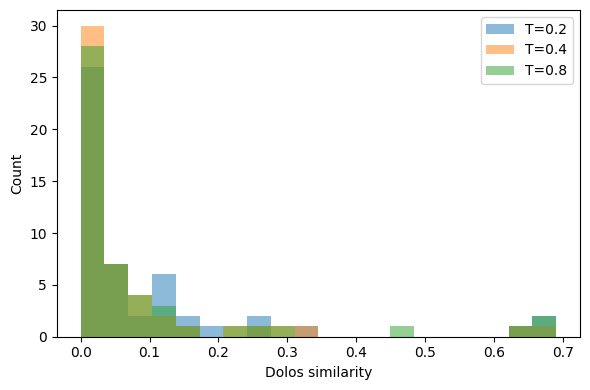

Saved plot to C:\Users\Feresh\Documents\EPRP_Final\data\plots\similarity_hist_scala.png


In [145]:
import matplotlib.pyplot as plt
from pathlib import Path

plt.figure(figsize=(6, 4))
for temp in sorted(df["temperature"].unique()):
    subset = df[df["temperature"] == temp]
    plt.hist(subset["similarity"], bins=20, alpha=0.5, label=f"T={temp}")
plt.xlabel("Dolos similarity")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()

# Save to file
plots_dir = DATA_DIR / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)
out_path = plots_dir / f"similarity_hist_{LANGUAGE}.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")

plt.show()
print("Saved plot to", out_path)


In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure function_id exists
if "function_id" not in df.columns:
    if "qualified_name" in df.columns:
        df["function_id"] = df["qualified_name"]
    else:
        df["function_id"] = np.arange(len(df)).astype(str)

# Ensure model exists (temporary if you're still on 1 model)
if "model" not in df.columns:
    df["model"] = "MODEL_1"


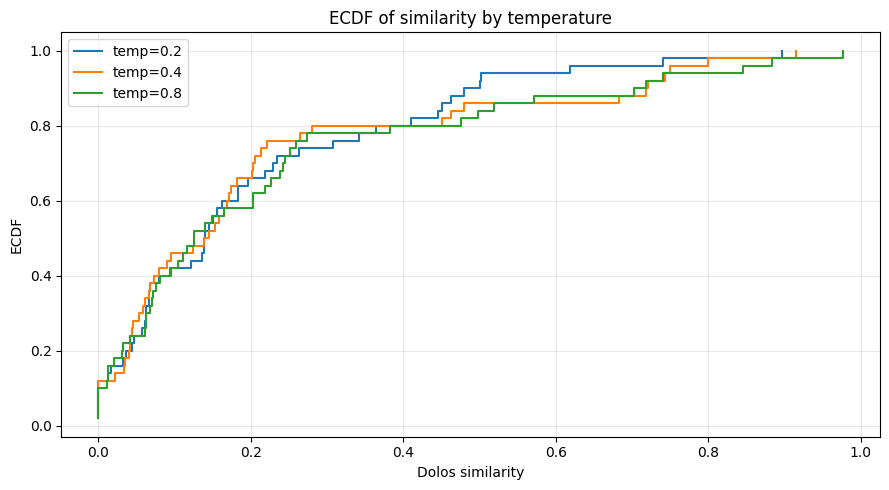

In [146]:
def plot_ecdf(data, label=None):
    x = np.sort(data)
    y = np.arange(1, len(x) + 1) / len(x)
    plt.step(x, y, where="post", label=label)

plt.figure(figsize=(9, 5))

# Example: compare temperatures (within one model+language)
for temp in sorted(df["temperature"].unique()):
    d = df.loc[df["temperature"] == temp, "similarity"].dropna().values
    plot_ecdf(d, label=f"temp={temp}")

plt.xlabel("Dolos similarity")
plt.ylabel("ECDF")
plt.title("ECDF of similarity by temperature")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


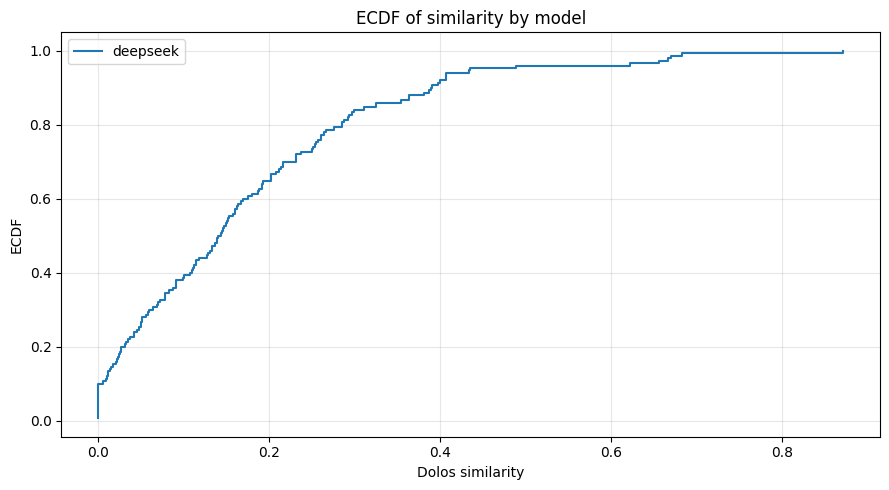

In [109]:
plt.figure(figsize=(9, 5))
for m in sorted(df["model"].unique()):
    d = df.loc[df["model"] == m, "similarity"].dropna().values
    plot_ecdf(d, label=m)

plt.xlabel("Dolos similarity")
plt.ylabel("ECDF")
plt.title("ECDF of similarity by model")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


C:\Users\Feresh\AppData\Local\Temp\ipykernel_10168\3009624786.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=True)


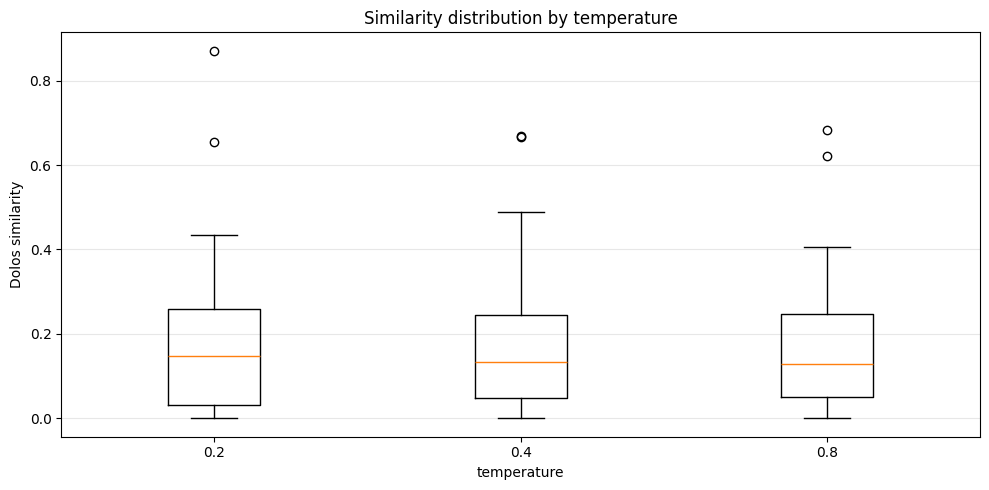

In [110]:
def boxplot_by_group(df, group_col, title):
    groups = []
    labels = []
    for g in sorted(df[group_col].unique()):
        vals = df.loc[df[group_col] == g, "similarity"].dropna().values
        if len(vals) == 0:
            continue
        groups.append(vals)
        labels.append(str(g))

    plt.figure(figsize=(10, 5))
    plt.boxplot(groups, labels=labels, showfliers=True)
    plt.xlabel(group_col)
    plt.ylabel("Dolos similarity")
    plt.title(title)
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

boxplot_by_group(df, "temperature", "Similarity distribution by temperature")
# later:
# boxplot_by_group(df, "model", "Similarity distribution by model")
# boxplot_by_group(df, "language", "Similarity distribution by language")
